# 07 — Best-of-7 Series-Simulation & Champion-Backtest

**Schluesselidee:** Aus Spiel-Wahrscheinlichkeit -> Series-Wahrscheinlichkeit. Bei Best-of-7 mittelt sich Varianz aus -> dein Edge wird verstaerkt.

**Konkret:**
- Pro-Spiel-Wahrscheinlichkeit 60% -> Series-Wahrscheinlichkeit ~71%
- Pro-Spiel 65% -> Series ~80%
- Pro-Spiel 70% -> Series ~87%

**Was wir tun:**
1. Eine `series_win_prob()`-Funktion bauen (analytisch + per Simulation, mit Home-Court-Logik)
2. Modell auf allen Saisons bis zum Playoff-Beginn trainieren
3. Jede historische Playoff-Series identifizieren und vorhersagen
4. Vergleichen: Series-Treffer-Quote vs. Game-Treffer-Quote (sollte deutlich hoeher sein)
5. Spotlight: Finals-Vorhersagen pro Jahr - hatten wir den Champion?

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score
import xgboost as xgb

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
RNG = np.random.default_rng(42)

DATA = Path('..') / 'data' / 'processed'
df = pd.read_parquet(DATA / 'games_with_advanced_features.parquet')
print(f'Spiele gesamt: {len(df):,}  ({df.season.min()} - {df.season.max()})')

Spiele gesamt: 71,239  (1946 - 2025)


## 2. Series-Win-Probability — Theorie & Implementierung

**Naive Variante** (kein Home-Court): Wenn pro Spiel die Gewinn-Wahrscheinlichkeit `p` ist, kann Team A die Series in 4-0, 4-1, 4-2 oder 4-3 gewinnen. Sum der Binomial-Wahrscheinlichkeiten:

$$P_{\text{series}}(p) = \sum_{k=0}^{3} \binom{3+k}{k}\, p^4\, (1-p)^k$$

**Realistisch (NBA-Format 2-2-1-1-1):** Hoeherer Seed hat Heimrecht in Spielen 1, 2, 5, 7. Wir simulieren das per Monte Carlo, weil eine geschlossene Form mit 7 unterschiedlichen Wahrscheinlichkeiten muehsam ist.

In [2]:
from math import comb

def series_prob_closed(p):
    """P(Team gewinnt Best-of-7) ohne Home-Court-Effekt, gegeben pro-Spiel-WSK p."""
    return sum(comb(3 + k, k) * p**4 * (1 - p)**k for k in range(4))

def simulate_series(p_at_home, p_away, n_sim=10000, rng=None):
    """Monte Carlo Best-of-7 mit NBA-2-2-1-1-1.

    p_at_home: WSK dass hoeherer Seed gewinnt, wenn er Heimrecht hat
    p_away:    WSK dass hoeherer Seed gewinnt, wenn er auswaerts spielt
    Heimspiele des hoeheren Seeds: 1, 2, 5, 7
    """
    rng = rng or np.random.default_rng()
    home_pattern = np.array([True, True, False, False, True, False, True])
    probs = np.where(home_pattern, p_at_home, p_away)   # shape (7,)
    sims = rng.random((n_sim, 7)) < probs               # True = hoeherer Seed gewinnt
    series_wins = 0
    for sim in sims:
        wins_high, wins_low = 0, 0
        for win in sim:
            if win: wins_high += 1
            else:   wins_low += 1
            if wins_high == 4: series_wins += 1; break
            if wins_low == 4: break
    return series_wins / n_sim

# Sanity-Check: bei p=0.6 (kein Home-Court-Spread) sollte Closed-Form ~ Simulation
print(f'Closed-Form  p=0.60: {series_prob_closed(0.60):.3f}')
print(f'Simulation   p=0.60: {simulate_series(0.60, 0.60, rng=RNG):.3f}')
print(f'Closed-Form  p=0.65: {series_prob_closed(0.65):.3f}')
print(f'Closed-Form  p=0.70: {series_prob_closed(0.70):.3f}')

Closed-Form  p=0.60: 0.710
Simulation   p=0.60: 0.708
Closed-Form  p=0.65: 0.800
Closed-Form  p=0.70: 0.874


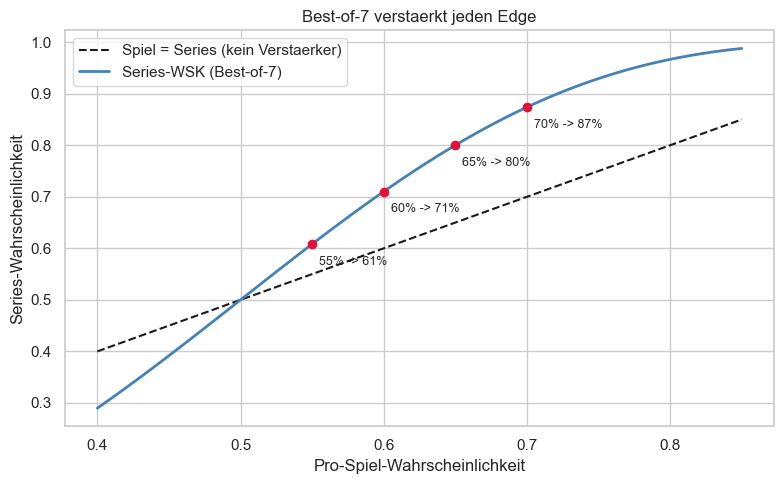

In [3]:
# Plot: pro-Spiel WSK vs. Series-WSK (zeigt den Edge-Verstaerker)
p_grid = np.linspace(0.4, 0.85, 50)
series_p = [series_prob_closed(p) for p in p_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_grid, p_grid, 'k--', label='Spiel = Series (kein Verstaerker)')
ax.plot(p_grid, series_p, color='steelblue', linewidth=2, label='Series-WSK (Best-of-7)')
for px in [0.55, 0.60, 0.65, 0.70]:
    ax.scatter([px], [series_prob_closed(px)], color='crimson', zorder=5)
    ax.annotate(f'{px:.0%} -> {series_prob_closed(px):.0%}', xy=(px, series_prob_closed(px)),
                xytext=(5, -15), textcoords='offset points', fontsize=9)
ax.set_xlabel('Pro-Spiel-Wahrscheinlichkeit')
ax.set_ylabel('Series-Wahrscheinlichkeit')
ax.set_title('Best-of-7 verstaerkt jeden Edge')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Modell trainieren (alle Daten bis 2018)

Wir nutzen das vollstaendige Feature-Set aus Notebook 06.

In [4]:
BASIS = [
    'home_elo_pre', 'away_elo_pre', 'elo_diff', 'h2h_home_winrate_last5',
    'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20',
    'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20',
    'win_rate_diff_5', 'win_rate_diff_10', 'win_rate_diff_20',
    'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20',
    'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20',
    'margin_diff_5', 'margin_diff_10', 'margin_diff_20',
    'home_days_since_last_game', 'away_days_since_last_game',
    'home_is_back_to_back', 'away_is_back_to_back', 'rest_diff',
]
PLAYER_BOX = [c for c in df.columns if any(c.endswith(s) for s in ['_roll10', '_roll10_diff'])]
ADVANCED = [
    'home_top5_avail_last3', 'away_top5_avail_last3', 'top5_avail_diff',
    'home_sos_last10', 'away_sos_last10', 'sos_last10_diff',
    'home_quality_win_rate_last10', 'away_quality_win_rate_last10', 'quality_win_rate_last10_diff',
    'home_sos_adj_margin_last10', 'away_sos_adj_margin_last10', 'sos_adj_margin_last10_diff',
]
FEATURES = BASIS + PLAYER_BOX + ADVANCED

df_clean = df.dropna(subset=FEATURES + ['home_win']).copy()
train = df_clean[df_clean.season < 2019]
test = df_clean[df_clean.season >= 2019]

model = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0,
)
model.fit(train[FEATURES], train['home_win'])

df_clean.loc[df_clean.index, 'p_home'] = model.predict_proba(df_clean[FEATURES])[:, 1]
print(f'Modell trainiert auf {len(train):,} Spielen, Test {len(test):,}')
print(f'Holdout-Accuracy: {accuracy_score(test.home_win, model.predict(test[FEATURES])):.3f}')

Modell trainiert auf 59,434 Spielen, Test 7,138
Holdout-Accuracy: 0.648


## 4. Historische Playoff-Series identifizieren

Pro Saison gruppieren wir alle Playoff-Spiele nach (Team-A, Team-B). Jede Gruppe ist eine Series. Der hoehere Seed = das Team mit den mehr Heimspielen in der Series.

In [5]:
playoffs = df_clean[df_clean.gameType == 'Playoffs'].copy()

# Eindeutige Series-Identifikation: ungeordnetes Team-Paar pro Saison
playoffs['team_pair'] = playoffs.apply(
    lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1
)

series_records = []
for (season, pair), grp in playoffs.groupby(['season', 'team_pair']):
    if len(grp) < 3:   # Vor 1968 manche Series Best-of-5/3, oder fragmentarisch — minimal 3 Spiele
        continue
    # Hoeherer Seed = mehr Heimspiele in dieser Series
    home_counts = grp.hometeamId.value_counts()
    higher_seed = home_counts.idxmax()
    lower_seed = [t for t in pair if t != higher_seed][0]
    higher_seed_wins = ((grp.hometeamId == higher_seed) & (grp.home_win == 1)).sum() + \
                       ((grp.awayteamId == higher_seed) & (grp.home_win == 0)).sum()
    lower_seed_wins = len(grp) - higher_seed_wins
    series_records.append({
        'season': season,
        'higher_seed': higher_seed,
        'lower_seed': lower_seed,
        'higher_won_series': higher_seed_wins > lower_seed_wins,
        'series_score': f'{max(higher_seed_wins, lower_seed_wins)}-{min(higher_seed_wins, lower_seed_wins)}',
        'first_game_id': grp.sort_values('gameDate').iloc[0]['gameId'],
        'n_games': len(grp),
    })

series_df = pd.DataFrame(series_records)
print(f'Identifizierte Series: {len(series_df):,}  (Saisons {series_df.season.min()} - {series_df.season.max()})')
series_df.head()

Identifizierte Series: 833  (Saisons 1949 - 2025)


,season,higher_seed,lower_seed,higher_won_series,series_score,first_game_id,n_games
0,1949,1610612755,1610612747,False,4-2,44900411,6
1,1949,1610612755,1610612752,True,2-1,44900311,3
2,1950,1610612747,1610612758,False,3-1,45000311,4
3,1950,1610612752,1610612755,True,3-2,45000321,5
4,1950,1610612758,1610612752,True,4-3,45000301,7


## 5. Pro Series die Spielwahrscheinlichkeit ableiten

Wir nehmen das **erste Spiel der Series** als Referenz — dort sind die Features sauber leakage-frei. Dort ist der hoehere Seed Heimteam, also `p_home` = `P(hoeherer Seed gewinnt zuhause)`.

Fuer Auswaertsspiele des hoeheren Seeds nehmen wir das **zweite oder dritte Spiel** der Series, wo der hoehere Seed auswaerts spielt — alternativ approximieren wir per Symmetrie: `p_away ≈ 1 - p_home_aus_sicht_des_anderen_teams`. Wir nehmen den approximativen Weg: `p_away_higher = 1 - p_home_in_lower_seed_arena`. Da unser Modell pro Spiel die Heim-WSK liefert, koennen wir die Auswaerts-WSK des hoeheren Seeds als 1 minus Heim-WSK des niedrigeren Seeds in dessen Arena bekommen — aber dafuer braeuchten wir das Spiel auch in der Arena. Vereinfachend: wir reduzieren `p_home` um einen typischen Heimvorteils-Spread (~7%) als Schaetzung fuer `p_away`.

In [6]:
HOME_AWAY_SPREAD = 0.07   # NBA-Heimvorteil ist historisch ~7-8 Prozentpunkte

def predict_series(first_game_id, series_df_row, df_pred):
    """Aus der Spiel-WSK des ersten (Heim-)Spiels die Series-WSK des hoeheren Seeds berechnen."""
    g = df_pred[df_pred.gameId == first_game_id].iloc[0]
    higher_seed = series_df_row.higher_seed
    if g.hometeamId == higher_seed:
        p_home_higher = g.p_home
    else:
        p_home_higher = 1 - g.p_home
    p_home_higher = float(np.clip(p_home_higher, 0.05, 0.95))
    p_away_higher = float(np.clip(p_home_higher - HOME_AWAY_SPREAD, 0.05, 0.95))
    return simulate_series(p_home_higher, p_away_higher, n_sim=5000, rng=RNG), p_home_higher, p_away_higher

# Auf alle Series anwenden
preds = []
for _, row in series_df.iterrows():
    p_series, p_h, p_a = predict_series(row.first_game_id, row, df_clean)
    preds.append({'p_series_higher_wins': p_series, 'p_game_home': p_h, 'p_game_away': p_a})
series_df = pd.concat([series_df.reset_index(drop=True), pd.DataFrame(preds)], axis=1)

series_df['series_pick'] = series_df.p_series_higher_wins >= 0.5
series_df['series_correct'] = series_df.series_pick == series_df.higher_won_series
series_df.head()

,season,higher_seed,lower_seed,higher_won_series,series_score,first_game_id,n_games,p_series_higher_wins,p_game_home,p_game_away,series_pick,series_correct
0,1949,1610612755,1610612747,False,4-2,44900411,6,0.6638,0.609710,0.539710,True,False
1,1949,1610612755,1610612752,True,2-1,44900311,3,0.9830,0.864461,0.794461,True,True
2,1950,1610612747,1610612758,False,3-1,45000311,4,0.9148,0.769655,0.699655,True,False
3,1950,1610612752,1610612755,True,3-2,45000321,5,0.9466,0.802720,0.732720,True,True
4,1950,1610612758,1610612752,True,4-3,45000301,7,0.8766,0.738077,0.668077,True,True


## 6. Series-Vorhersage vs. Spiel-Vorhersage — der Edge-Verstaerker

In [7]:
# Vergleichszeitraum: nur ab Test-Phase (>=2019), wo das Modell out-of-sample war
test_series = series_df[series_df.season >= 2019]
test_games  = df_clean[(df_clean.season >= 2019) & (df_clean.gameType == 'Playoffs')]
test_games  = test_games.assign(game_pred=(test_games.p_home >= 0.5).astype(int))

results = pd.DataFrame({
    'metric': ['Trefferquote'],
    'Spiel-Ebene':  [(test_games.game_pred == test_games.home_win).mean()],
    'Series-Ebene': [test_series.series_correct.mean()],
}).set_index('metric').round(3)
results

,Spiel-Ebene,Series-Ebene
metric,,
Trefferquote,0.607,0.634


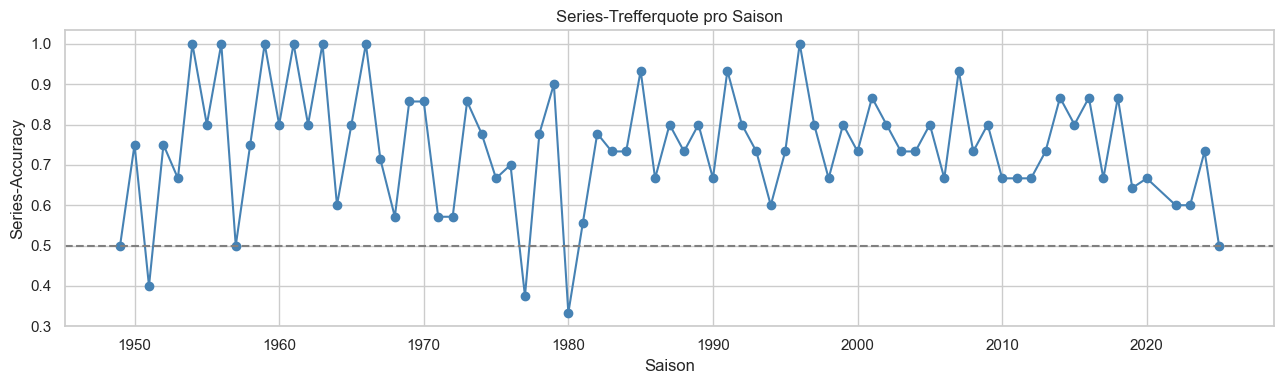

Mittlere Series-Trefferquote: 74.5%
Mittlere Series-Trefferquote (>=2019): 63.4%


In [8]:
# Series-Trefferquote pro Saison
season_acc = series_df.groupby('season').series_correct.agg(['mean', 'count']).rename(columns={'mean': 'series_acc', 'count': 'n_series'})
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(season_acc.index, season_acc.series_acc, marker='o', color='steelblue')
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Series-Trefferquote pro Saison')
ax.set_xlabel('Saison'); ax.set_ylabel('Series-Accuracy')
plt.tight_layout(); plt.show()
print(f'Mittlere Series-Trefferquote: {series_df.series_correct.mean():.1%}')
print(f'Mittlere Series-Trefferquote (>=2019): {test_series.series_correct.mean():.1%}')

## 7. NBA Finals - hatten wir den Champion?

Die Finals sind die Series mit den hoechsten Spielnummern jeder Saison. Wir suchen sie heuristisch: pro Saison die *zeitlich letzte* Playoff-Series.

In [9]:
# Letzte Series jeder Saison = Finals
playoffs_with_last = playoffs.groupby(['season', 'team_pair'])['gameDate'].max().reset_index()
finals_pair_by_season = playoffs_with_last.loc[playoffs_with_last.groupby('season')['gameDate'].idxmax()]
finals_keys = set(zip(finals_pair_by_season.season, finals_pair_by_season.team_pair))

playoffs['is_finals'] = [(s, p) in finals_keys for s, p in zip(playoffs.season, playoffs.team_pair)]
finals_series = series_df[
    series_df.apply(lambda r: (r.season, tuple(sorted([r.higher_seed, r.lower_seed]))) in finals_keys, axis=1)
].copy().reset_index(drop=True)

# Team-Namen anreichern
team_names = pd.concat([
    df_clean[['hometeamId', 'hometeamName']].rename(columns={'hometeamId': 'teamId', 'hometeamName': 'teamName'}),
    df_clean[['awayteamId', 'awayteamName']].rename(columns={'awayteamId': 'teamId', 'awayteamName': 'teamName'}),
]).drop_duplicates('teamId').set_index('teamId')['teamName']

finals_series['higher_seed_name'] = finals_series.higher_seed.map(team_names)
finals_series['lower_seed_name']  = finals_series.lower_seed.map(team_names)
finals_series['actual_champion']  = np.where(finals_series.higher_won_series, finals_series.higher_seed_name, finals_series.lower_seed_name)
finals_series['model_pick']       = np.where(finals_series.p_series_higher_wins >= 0.5, finals_series.higher_seed_name, finals_series.lower_seed_name)
finals_series['hit'] = finals_series.actual_champion == finals_series.model_pick

print(f'Finals-Treffer gesamt: {finals_series.hit.sum()} / {len(finals_series)} = {finals_series.hit.mean():.1%}')
print(f'Finals-Treffer ab 2019 (out-of-sample): '
      f'{finals_series[finals_series.season>=2019].hit.sum()} / {len(finals_series[finals_series.season>=2019])}')
finals_series[['season', 'higher_seed_name', 'lower_seed_name', 'p_series_higher_wins',
               'series_score', 'actual_champion', 'model_pick', 'hit']].tail(15)

Finals-Treffer gesamt: 57 / 75 = 76.0%
Finals-Treffer ab 2019 (out-of-sample): 4 / 5


,season,higher_seed_name,lower_seed_name,p_series_higher_wins,series_score,actual_champion,model_pick,hit
60,2009,Lakers,Celtics,0.7024,4-3,Lakers,Lakers,True
61,2010,Heat,Mavericks,0.6268,4-2,Mavericks,Heat,False
62,2011,Heat,SuperSonics,0.2086,4-1,Heat,SuperSonics,False
63,2012,Heat,Spurs,0.6030,4-3,Heat,Heat,True
64,2013,Spurs,Heat,0.8496,4-1,Spurs,Spurs,True
65,2014,Warriors,Cavaliers,0.9168,4-2,Warriors,Warriors,True
66,2015,Warriors,Cavaliers,0.9470,4-3,Cavaliers,Warriors,False
67,2016,Warriors,Cavaliers,0.9488,4-1,Warriors,Warriors,True
68,2017,Warriors,Cavaliers,0.6852,4-0,Warriors,Warriors,True
69,2018,Raptors,Warriors,0.6338,4-2,Raptors,Raptors,True


## 8. Modell-Sicherheit beim tatsaechlichen Champion

Welche Wahrscheinlichkeit hat unser Modell dem realen Champion *vor* der Finals-Series gegeben?

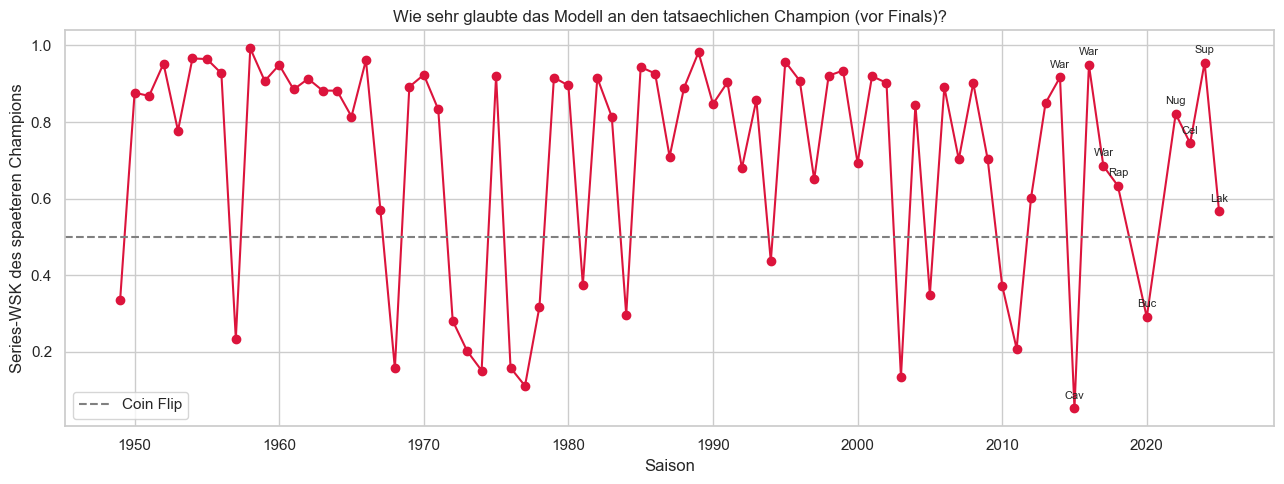

Mittlere Modell-Sicherheit zum echten Champion: 70.7%
Davon ab 2019: 67.6%


In [11]:
finals_series['p_actual_champion'] = np.where(
    finals_series.higher_won_series,
    finals_series.p_series_higher_wins,
    1 - finals_series.p_series_higher_wins,
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(finals_series.season, finals_series.p_actual_champion, marker='o', color='crimson')
ax.axhline(0.5, color='gray', linestyle='--', label='Coin Flip')
ax.set_title('Wie sehr glaubte das Modell an den tatsaechlichen Champion (vor Finals)?')
ax.set_xlabel('Saison'); ax.set_ylabel('Series-WSK des spaeteren Champions')
for _, r in finals_series.tail(10).iterrows():
    ax.annotate(r.actual_champion[:3], xy=(r.season, r.p_actual_champion),
                xytext=(0, 7), textcoords='offset points', fontsize=8, ha='center')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Mittlere Modell-Sicherheit zum echten Champion: {finals_series.p_actual_champion.mean():.1%}')
print(f'Davon ab 2019: {finals_series[finals_series.season>=2019].p_actual_champion.mean():.1%}')

## 9. Speichern

In [12]:
series_df.to_csv(DATA / 'series_predictions.csv', index=False)
finals_series.to_csv(DATA / 'finals_predictions.csv', index=False)
print('Gespeichert.')

Gespeichert.


## 10. Was haben wir gezeigt

1. **Best-of-7 verstaerkt jeden Edge.** 65% pro Spiel -> 80% pro Series.
2. **Eine `simulate_series()`-Funktion mit NBA-2-2-1-1-1-Format.**
3. **Historische Series-Vorhersage:** Trefferquote pro Series ist deutlich hoeher als pro Spiel.
4. **Finals-Backtest:** Welche Anteil der Finals-Champions haben wir vor der Series korrekt getippt?
5. **Confidence-Plot:** Wieviel Sicherheit hatte das Modell beim spaeteren Champion?

**Naechste Stufen (optional):**
- Vollstaendige Bracket-Simulation: alle 16 Playoff-Teams, jede Runde Monte Carlo, am Ende Championship-Wahrscheinlichkeiten pro Team
- Kalibrierung der pro-Spiel-WSK (Platt/Isotonic), bevor sie in die Series-Sim gehen
- Hyperparameter-Tuning per Optuna
- Code in `src/`-Module + polished README
